In [1]:
using PowerPlots
using PowerModels

# Parse the MATPOWER case
sys = PowerModels.parse_file("../cases/case2383wp.m")
# sys = PowerModels.parse_file("../cases/case14.m")

plot = powerplot(sys;
    width = 2000, height = 2000,
    fixed = false,                         # allow layout algorithm to place nodes
    node = (:size => 3),                   # << much smaller than default 500
    branch = (:size => 1),                 # thin branches
)

display(plot)



LoadError: ArgumentError: Package PowerPlots not found in current path.
- Run `import Pkg; Pkg.add("PowerPlots")` to install the PowerPlots package.

Found 3 connected components:
Component 1 buses: ["1", "100", "1000", "1001", "1002", "1003", "1004", "1005", "1006", "1007", "1008", "1009", "101", "1010", "1011", "1012", "1013", "1014", "1015", "1016", "1017", "1018", "1019", "102", "1020", "1021", "1022", "1023", "1024", "1025", "1026", "1027", "1028", "1029", "103", "1030", "1031", "1032", "1033", "1034", "1035", "1036", "1037", "1038", "1039", "104", "1040", "1041", "1042", "1043", "1044", "1045", "1046", "1047", "1048", "1049", "105", "1050", "1051", "1052", "1053", "1054", "1055", "1056", "1057", "1058", "1059", "106", "1060", "1061", "1062", "1063", "1064", "1065", "1066", "1067", "1068", "1069", "107", "1070", "1071", "1072", "1073", "1074", "1075", "1076", "1077", "1078", "1079", "108", "1080", "1081", "1082", "1083", "1084", "1085", "1086", "1087", "1088", "1089", "109", "1090", "1091", "1092", "1093", "1094", "1095", "1096", "1097", "1098", "1099", "110", "1100", "1101", "1102", "1103", "1104", "1105", "1106", "1107", "110

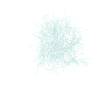

In [2]:
using Graphs
using GraphPlot

# Use same MATPOWER or JSON case

# Build undirected graph from buses and branches
bus_ids = sort(collect(keys(sys["bus"])))
bus_index = Dict(bus_id => i for (i, bus_id) in enumerate(bus_ids))

# Create sparse graph of our grid
g = SimpleGraph(length(bus_ids))

# Add branches to the graph
for branch in values(sys["branch"])
        f = branch["f_bus"]
        t = branch["t_bus"]

        #Island Invoker (prevents branches from connecting to certain buses)
        if f in [10, 11] || t in [10, 11]
            continue
        end
        # Add branch as an edge to our sparse graph
        add_edge!(g, bus_index[string(f)], bus_index[string(t)])
end

# Get connected components
components = connected_components(g)

println("Found $(length(components)) connected components:")
for (i, comp) in enumerate(components)
    println("Component $i buses: ", [bus_ids[j] for j in comp])
end

gplot(g, layout=spring_layout)